In [1]:
import pandas as pd
import numpy as np

# Load data
expr = pd.read_csv("results/normalized_expression.csv")
meta = pd.read_csv("results/sample_metadata.csv")

# Extract timepoint and subject
meta["timepoint"] = meta["characteristics"].str.extract(r"t(\d+)").astype(int)
meta["subject"] = meta["title"].str.extract(r"subject (\d+)")

# Assign phase from paper
def assign_phase(t):
    if 1 <= t <= 4:
        return "baseline"
    elif 5 <= t <= 8:
        return "experimental"
    elif 9 <= t <= 12:
        return "recovery"
    return np.nan

meta["phase"] = meta["timepoint"].apply(assign_phase)

print(expr.shape)
print(meta.shape)
print(meta[["sample_id", "subject", "timepoint", "phase", "condition"]].head(12))
print(meta["phase"].value_counts())

(8506, 164)
(163, 8)
     sample_id subject  timepoint         phase     condition
0   GSM2600155    6045          1      baseline  normal_sleep
1   GSM2600156    6045          2      baseline  normal_sleep
2   GSM2600157    6045          3      baseline  normal_sleep
3   GSM2600158    6045          4      baseline  normal_sleep
4   GSM2600159    6045          5  experimental  normal_sleep
5   GSM2600160    6045          6  experimental  normal_sleep
6   GSM2600161    6045          8  experimental  normal_sleep
7   GSM2600162    6045          9      recovery  normal_sleep
8   GSM2600163    6045         10      recovery  normal_sleep
9   GSM2600164    6045         11      recovery  normal_sleep
10  GSM2600165    6045         12      recovery  normal_sleep
11  GSM2600166    6068          1      baseline  normal_sleep
phase
experimental    55
recovery        55
baseline        53
Name: count, dtype: int64


In [3]:
# Check phase distribution by condition
phase_summary = meta.groupby(["phase", "condition"]).size().unstack(fill_value=0)

print(phase_summary)

condition     normal_sleep  sleep_deprived
phase                                     
baseline                24              29
experimental            23              32
recovery                24              31


In [5]:
# Merge expression with metadata
expr_long = expr.melt(id_vars=["ID_REF"], var_name="sample_id", value_name="expression")

merged = expr_long.merge(meta, on="sample_id")

print(merged.head())
print(merged.shape)

    ID_REF   sample_id  expression  \
0  7896742  GSM2600155    7.609771   
1  7896746  GSM2600155    8.011875   
2  7896748  GSM2600155    4.970357   
3  7896750  GSM2600155    4.681245   
4  7896752  GSM2600155    8.864139   

                                           title source characteristics  \
0  Control subject 6045 blood collection 01 [D9]  blood  timepoint: t01   
1  Control subject 6045 blood collection 01 [D9]  blood  timepoint: t01   
2  Control subject 6045 blood collection 01 [D9]  blood  timepoint: t01   
3  Control subject 6045 blood collection 01 [D9]  blood  timepoint: t01   
4  Control subject 6045 blood collection 01 [D9]  blood  timepoint: t01   

      condition  timepoint subject     phase  
0  normal_sleep          1    6045  baseline  
1  normal_sleep          1    6045  baseline  
2  normal_sleep          1    6045  baseline  
3  normal_sleep          1    6045  baseline  
4  normal_sleep          1    6045  baseline  
(1386478, 10)


In [7]:
# Average expression within each subject and phase
phase_subject_avg = (
    merged
    .groupby(["ID_REF", "subject", "condition", "phase"])["expression"]
    .mean()
    .reset_index()
)

print(phase_subject_avg.head())
print(phase_subject_avg.shape)
print(phase_subject_avg["phase"].value_counts())

    ID_REF subject     condition         phase  expression
0  7896742    6045  normal_sleep      baseline    7.370752
1  7896742    6045  normal_sleep  experimental    7.302376
2  7896742    6045  normal_sleep      recovery    6.892180
3  7896742    6068  normal_sleep      baseline    6.545722
4  7896742    6068  normal_sleep  experimental    6.962400
(357252, 5)
phase
baseline        119084
experimental    119084
recovery        119084
Name: count, dtype: int64


In [9]:
phase_wide = phase_subject_avg.pivot_table(
    index=["ID_REF", "subject", "condition"],
    columns="phase",
    values="expression"
).reset_index()

print(phase_wide.head())
print(phase_wide.shape)

phase   ID_REF subject       condition  baseline  experimental  recovery
0      7896742    6045    normal_sleep  7.370752      7.302376  6.892180
1      7896742    6068    normal_sleep  6.545722      6.962400  7.187665
2      7896742    6089    normal_sleep  7.646717      7.730634  7.841478
3      7896742    6166  sleep_deprived  7.259386      7.329168  7.008293
4      7896742    6207  sleep_deprived  7.199320      6.847710  7.321787
(119084, 6)


In [11]:
# Normalize experimental and recovery to baseline for each subject
phase_wide["exp_over_base"] = phase_wide["experimental"] / (phase_wide["baseline"] + 1e-8)
phase_wide["rec_over_base"] = phase_wide["recovery"] / (phase_wide["baseline"] + 1e-8)

print(phase_wide.head())

phase   ID_REF subject       condition  baseline  experimental  recovery  \
0      7896742    6045    normal_sleep  7.370752      7.302376  6.892180   
1      7896742    6068    normal_sleep  6.545722      6.962400  7.187665   
2      7896742    6089    normal_sleep  7.646717      7.730634  7.841478   
3      7896742    6166  sleep_deprived  7.259386      7.329168  7.008293   
4      7896742    6207  sleep_deprived  7.199320      6.847710  7.321787   

phase  exp_over_base  rec_over_base  
0           0.990723       0.935071  
1           1.063656       1.098071  
2           1.010974       1.025470  
3           1.009613       0.965411  
4           0.951161       1.017011  


In [13]:
from scipy.stats import ttest_ind

# Compare ratios between case and control
ratio_results = []

for gene, group in phase_wide.groupby("ID_REF"):
    
    case = group[group["condition"] == "sleep_deprived"]
    control = group[group["condition"] == "normal_sleep"]
    
    if len(case) > 1 and len(control) > 1:
        exp_p = ttest_ind(case["exp_over_base"], control["exp_over_base"], equal_var=False).pvalue
        rec_p = ttest_ind(case["rec_over_base"], control["rec_over_base"], equal_var=False).pvalue
        
        ratio_results.append((gene,
                              case["exp_over_base"].mean(),
                              control["exp_over_base"].mean(),
                              exp_p,
                              case["rec_over_base"].mean(),
                              control["rec_over_base"].mean(),
                              rec_p))

ratio_df = pd.DataFrame(ratio_results, columns=[
    "ID_REF",
    "case_exp_mean", "control_exp_mean", "exp_p_value",
    "case_rec_mean", "control_rec_mean", "rec_p_value"
])

print(ratio_df.head())
print(ratio_df.shape)

    ID_REF  case_exp_mean  control_exp_mean  exp_p_value  case_rec_mean  \
0  7896742       0.973364          1.016700     0.120915       0.984314   
1  7896746       1.002410          1.011083     0.555833       1.018593   
2  7896748       1.030992          1.026248     0.915726       1.025810   
3  7896750       1.017407          1.029583     0.763954       1.052040   
4  7896752       0.998419          1.011282     0.416332       1.013355   

   control_rec_mean  rec_p_value  
0          1.022372     0.239513  
1          1.019689     0.933518  
2          1.043344     0.715182  
3          1.081340     0.499763  
4          1.031174     0.390178  
(8506, 7)


In [14]:
# Multiple testing correction (FDR)
from statsmodels.stats.multitest import multipletests

ratio_df["exp_adj_p"] = multipletests(ratio_df["exp_p_value"], method="fdr_bh")[1]
ratio_df["rec_adj_p"] = multipletests(ratio_df["rec_p_value"], method="fdr_bh")[1]

# Mark significant genes
ratio_df["exp_significant"] = ratio_df["exp_adj_p"] < 0.05
ratio_df["rec_significant"] = ratio_df["rec_adj_p"] < 0.05

print(ratio_df.sort_values("exp_adj_p").head(10))
print("Significant (Experimental phase):", ratio_df["exp_significant"].sum())

print(ratio_df.sort_values("rec_adj_p").head(10))
print("Significant (Recovery phase):", ratio_df["rec_significant"].sum())

       ID_REF  case_exp_mean  control_exp_mean  exp_p_value  case_rec_mean  \
0     7896742       0.973364          1.016700     0.120915       0.984314   
4987  8063650       1.011200          0.988858     0.133670       1.003600   
4984  8063607       0.995998          0.985744     0.147540       1.007186   
4982  8063566       0.983498          1.005776     0.048258       0.991154   
4981  8063509       0.985535          0.994447     0.263945       0.986705   
4980  8063497       0.963140          0.994277     0.074118       0.984994   
4978  8063473       1.004890          0.999408     0.414963       1.002931   
4974  8063386       0.987466          1.001019     0.494048       0.994634   
4973  8063369       1.008147          0.994886     0.084833       1.005082   
4972  8063351       0.985531          1.000168     0.242702       0.974951   

      control_rec_mean  rec_p_value  exp_adj_p  rec_adj_p  exp_significant  \
0             1.022372     0.239513   0.968823   0.998894      

In [15]:
# Create ranking metric for pathway analysis
ratio_df["exp_diff"] = ratio_df["case_exp_mean"] - ratio_df["control_exp_mean"]
ratio_df["rec_diff"] = ratio_df["case_rec_mean"] - ratio_df["control_rec_mean"]

# Sort genes by strongest effect
exp_ranked = ratio_df.sort_values("exp_diff", ascending=False)
rec_ranked = ratio_df.sort_values("rec_diff", ascending=False)

print(exp_ranked[["ID_REF", "exp_diff"]].head(10))
print(rec_ranked[["ID_REF", "rec_diff"]].head(10))

       ID_REF  exp_diff
8230  8176375  0.099698
4030  8030362  0.096604
4459  8043446  0.092580
2557  7984008  0.089938
7685  8156358  0.084833
3759  8021470  0.081033
2684  7989013  0.080989
6801  8126095  0.075704
2503  7981943  0.074897
5557  8083592  0.074824
       ID_REF  rec_diff
4459  8043446  0.157153
8230  8176375  0.131557
8235  8176624  0.108415
5557  8083592  0.102190
691   7919600  0.096967
8245  8177137  0.092132
8236  8176698  0.087827
664   7919155  0.086088
678   7919405  0.083476
6384  8113035  0.083310


In [19]:
file_path = "results/GPL6244_family.soft"

start_idx = None
end_idx = None
header = None
n_table_lines = 0
preview = []

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f):
        if start_idx is None:
            if line.startswith("ID\t"):
                start_idx = i
                header = line.rstrip("\n")
        else:
            if line.startswith("!platform_table_end"):
                end_idx = i
                break
            n_table_lines += 1
            if len(preview) < 5:
                preview.append(line.rstrip("\n"))

print("Start:", start_idx)
print("End:", end_idx)
print("Header:", header)
print("Preview:")
for row in preview:
    print(row)
print("Number of table lines:", n_table_lines)

Start: 40608
End: 73906
Header: ID	GB_LIST	SPOT_ID	seqname	RANGE_GB	RANGE_STRAND	RANGE_START	RANGE_STOP	total_probes	gene_assignment	mrna_assignment	category
Preview:
7896736		chr1:53049-54936	chr1	NC_000001.10	+	53049	54936	7	---	NONHSAT060105 // NONCODE // Non-coding transcript identified by NONCODE // chr1 // 100 // 100 // 7 // 7 // 0	main
7896738		chr1:63015-63887	chr1	NC_000001.10	+	63015	63887	31	ENST00000328113 // OR4G2P // olfactory receptor, family 4, subfamily G, member 2 pseudogene // --- // --- /// ENST00000492842 // OR4G11P // olfactory receptor, family 4, subfamily G, member 11 pseudogene // --- // --- /// ENST00000588632 // OR4G1P // olfactory receptor, family 4, subfamily G, member 1 pseudogene // --- // ---	ENST00000328113 // ENSEMBL // havana:known chromosome:GRCh38:15:101926805:101927707:-1 gene:ENSG00000183909 gene_biotype:unprocessed_pseudogene transcript_biotype:unprocessed_pseudogene // chr1 // 100 // 100 // 31 // 31 // 0 /// ENST00000492842 // ENSEMBL // havana:

In [21]:
import pandas as pd

annot = pd.read_csv(
    file_path,
    sep="\t",
    skiprows=start_idx,
    nrows=n_table_lines,
    low_memory=False
)

print(annot.head())
print(annot.shape)

        ID                                            GB_LIST  \
0  7896736                                                NaN   
1  7896738                                                NaN   
2  7896740  NM_001004195,NM_001005240,NM_001005484,BC13684...   
3  7896742  NR_024437,XM_006711854,XM_006726377,XR_430662,...   
4  7896744  NM_001005221,NM_001005224,NM_001005277,NM_0010...   

              SPOT_ID seqname      RANGE_GB RANGE_STRAND RANGE_START  \
0    chr1:53049-54936    chr1  NC_000001.10            +       53049   
1    chr1:63015-63887    chr1  NC_000001.10            +       63015   
2    chr1:69091-70008    chr1  NC_000001.10            +       69091   
3  chr1:334129-334296    chr1  NC_000001.10            +      334129   
4  chr1:367659-368597    chr1  NC_000001.10            +      367659   

  RANGE_STOP  total_probes                                    gene_assignment  \
0      54936             7                                                ---   
1      63887  

In [23]:
import pandas as pd

annot = pd.read_csv(
    "results/GPL6244_family.soft",
    sep="\t",
    skiprows=40608,
    nrows=33297,
    low_memory=False
)

print(annot.head())
print(annot.shape)

        ID                                            GB_LIST  \
0  7896736                                                NaN   
1  7896738                                                NaN   
2  7896740  NM_001004195,NM_001005240,NM_001005484,BC13684...   
3  7896742  NR_024437,XM_006711854,XM_006726377,XR_430662,...   
4  7896744  NM_001005221,NM_001005224,NM_001005277,NM_0010...   

              SPOT_ID seqname      RANGE_GB RANGE_STRAND RANGE_START  \
0    chr1:53049-54936    chr1  NC_000001.10            +       53049   
1    chr1:63015-63887    chr1  NC_000001.10            +       63015   
2    chr1:69091-70008    chr1  NC_000001.10            +       69091   
3  chr1:334129-334296    chr1  NC_000001.10            +      334129   
4  chr1:367659-368597    chr1  NC_000001.10            +      367659   

  RANGE_STOP  total_probes                                    gene_assignment  \
0      54936             7                                                ---   
1      63887  

In [25]:
annot["ID_REF"] = annot["ID"].astype(str)
annot["Gene Symbol"] = annot["gene_assignment"].str.split(" // ").str[1]
annot["Gene Symbol"] = annot["Gene Symbol"].replace("---", pd.NA)

annot = annot[["ID_REF", "Gene Symbol"]].dropna()

print(annot.head(10))
print("Mapped probes:", annot.shape)

     ID_REF   Gene Symbol
1   7896738        OR4G2P
2   7896740         OR4F4
3   7896742     LOC728323
4   7896744        OR4F29
5   7896746         MT-TM
6   7896748         MT-TW
7   7896750         MT-TD
8   7896752         MT-TK
9   7896754  LOC100287497
10  7896756        FAM87B
Mapped probes: (25293, 2)


In [31]:
# Make sure ranked DE tables use string probe IDs
exp_ranked["ID_REF"] = exp_ranked["ID_REF"].astype(str)
rec_ranked["ID_REF"] = rec_ranked["ID_REF"].astype(str)

# Merge annotation
exp_annot = exp_ranked.merge(annot, on="ID_REF", how="left").dropna(subset=["Gene Symbol"])
rec_annot = rec_ranked.merge(annot, on="ID_REF", how="left").dropna(subset=["Gene Symbol"])

print(exp_annot.columns.tolist())
print(rec_annot.columns.tolist())
print(exp_annot[["ID_REF", "Gene Symbol", "exp_diff"]].head(10))
print(rec_annot[["ID_REF", "Gene Symbol", "rec_diff"]].head(10))
print("Experimental mapped:", exp_annot.shape)
print("Recovery mapped:", rec_annot.shape)

['ID_REF', 'case_exp_mean', 'control_exp_mean', 'exp_p_value', 'case_rec_mean', 'control_rec_mean', 'rec_p_value', 'exp_adj_p', 'rec_adj_p', 'exp_significant', 'rec_significant', 'exp_diff', 'rec_diff', 'Gene Symbol']
['ID_REF', 'case_exp_mean', 'control_exp_mean', 'exp_p_value', 'case_rec_mean', 'control_rec_mean', 'rec_p_value', 'exp_adj_p', 'rec_adj_p', 'exp_significant', 'rec_significant', 'exp_diff', 'rec_diff', 'Gene Symbol']
     ID_REF  Gene Symbol  exp_diff
0   8176375       RPS4Y1  0.099698
1   8030362      SNORD33  0.096604
2   8043446     IGKV6-21  0.092580
5   8021470       PMAIP1  0.081033
6   7989013      RSL24D1  0.080989
7   8126095      CCDC167  0.075704
8   7981943      SNORD64  0.074897
10  7981978  SNORD116-15  0.074780
11  7961075         CD69  0.074609
12  8012207      TMEM256  0.073047
     ID_REF Gene Symbol  rec_diff
0   8043446    IGKV6-21  0.157153
1   8176375      RPS4Y1  0.131557
2   8176624       DDX3Y  0.108415
5   8177137         UTY  0.092132
6   81766

In [33]:
top_exp_genes = (
    exp_annot.sort_values("exp_diff", ascending=False)["Gene Symbol"]
    .drop_duplicates()
    .head(200)
)

top_rec_genes = (
    rec_annot.sort_values("rec_diff", ascending=False)["Gene Symbol"]
    .drop_duplicates()
    .head(200)
)

print("Top experimental genes:")
print(top_exp_genes.tolist()[:20])

print("\nTop recovery genes:")
print(top_rec_genes.tolist()[:20])

Top experimental genes:
['RPS4Y1', 'SNORD33', 'IGKV6-21', 'PMAIP1', 'RSL24D1', 'CCDC167', 'SNORD64', 'SNORD116-15', 'CD69', 'TMEM256', 'PSMC6', 'CENPK', 'SNRPG', 'SNORD57', 'SYNJ2BP-COX16', 'RNVU1-2', 'RCN2', 'CMTM5', 'CCDC82', 'RPL34P34']

Top recovery genes:
['IGKV6-21', 'RPS4Y1', 'DDX3Y', 'UTY', 'TXLNGY', 'RNU1-13P', 'RNA5SP187', 'KIR2DS2', 'CXCL8', 'MEGF8', 'PMAIP1', 'RNY4P18', 'PRKXP1', 'CCDC167', 'IFIT5', 'RNVU1-2', 'RNU4ATAC16P', 'SNORA8', 'KLRF1', 'SET']


In [35]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

exp_enrich = gp.profile(
    organism="hsapiens",
    query=top_exp_genes.tolist()
)

rec_enrich = gp.profile(
    organism="hsapiens",
    query=top_rec_genes.tolist()
)

print(exp_enrich[["source", "native", "name", "p_value", "significant"]].head(10))
print(rec_enrich[["source", "native", "name", "p_value", "significant"]].head(10))

  source              native                                         name  \
0   KEGG          KEGG:03010                                     Ribosome   
1   REAC  REAC:R-HSA-9010553  Regulation of expression of SLITs and ROBOs   
2  GO:MF          GO:0003735           structural constituent of ribosome   
3  GO:CC          GO:0005840                                     ribosome   
4  GO:CC          GO:0044391                            ribosomal subunit   
5     WP            WP:WP477               Cytoplasmic ribosomal proteins   
6   REAC   REAC:R-HSA-376176                  Signaling by ROBO receptors   
7   REAC  REAC:R-HSA-2262752                 Cellular responses to stress   
8   REAC   REAC:R-HSA-192823                       Viral mRNA Translation   
9   REAC   REAC:R-HSA-156902                     Peptide chain elongation   

        p_value  significant  
0  1.399382e-08         True  
1  2.642502e-07         True  
2  5.636133e-07         True  
3  2.158274e-06         True

In [37]:
keep_sources = ["KEGG", "REAC", "GO:BP", "GO:MF", "GO:CC", "WP"]

exp_enrich_filt = exp_enrich[exp_enrich["source"].isin(keep_sources)].copy()
rec_enrich_filt = rec_enrich[rec_enrich["source"].isin(keep_sources)].copy()

print("Experimental phase enrichment:")
print(exp_enrich_filt[["source", "native", "name", "p_value", "significant"]].head(10))

print("\nRecovery phase enrichment:")
print(rec_enrich_filt[["source", "native", "name", "p_value", "significant"]].head(10))

Experimental phase enrichment:
  source              native                                         name  \
0   KEGG          KEGG:03010                                     Ribosome   
1   REAC  REAC:R-HSA-9010553  Regulation of expression of SLITs and ROBOs   
2  GO:MF          GO:0003735           structural constituent of ribosome   
3  GO:CC          GO:0005840                                     ribosome   
4  GO:CC          GO:0044391                            ribosomal subunit   
5     WP            WP:WP477               Cytoplasmic ribosomal proteins   
6   REAC   REAC:R-HSA-376176                  Signaling by ROBO receptors   
7   REAC  REAC:R-HSA-2262752                 Cellular responses to stress   
8   REAC   REAC:R-HSA-192823                       Viral mRNA Translation   
9   REAC   REAC:R-HSA-156902                     Peptide chain elongation   

        p_value  significant  
0  1.399382e-08         True  
1  2.642502e-07         True  
2  5.636133e-07         True

In [43]:
import pandas as pd
import numpy as np

expr = pd.read_csv("results/normalized_expression.csv")
meta = pd.read_csv("results/sample_metadata.csv")

meta["timepoint"] = meta["characteristics"].str.extract(r"t(\d+)").astype(int)
meta["subject"] = meta["title"].str.extract(r"subject (\d+)")

def assign_phase(t):
    if 1 <= t <= 4:
        return "baseline"
    elif 5 <= t <= 8:
        return "experimental"
    elif 9 <= t <= 12:
        return "recovery"
    return np.nan

meta["phase"] = meta["timepoint"].apply(assign_phase)

expr_long = expr.melt(id_vars=["ID_REF"], var_name="sample_id", value_name="expression")
full_df = expr_long.merge(
    meta[["sample_id", "subject", "condition", "timepoint", "phase"]],
    on="sample_id",
    how="left"
)

baseline_ref = (
    full_df[full_df["phase"] == "baseline"]
    .groupby(["ID_REF", "subject", "condition"])["expression"]
    .mean()
    .reset_index()
    .rename(columns={"expression": "baseline_expr"})
)

norm_df = full_df.merge(
    baseline_ref,
    on=["ID_REF", "subject", "condition"],
    how="left"
)

norm_df["norm_expr"] = norm_df["expression"] / (norm_df["baseline_expr"] + 1e-8)

de_df = norm_df[norm_df["phase"].isin(["experimental", "recovery"])].copy()

print(de_df.head())
print(de_df.shape)
print(de_df["phase"].value_counts())

        ID_REF   sample_id  expression subject     condition  timepoint  \
34024  7896742  GSM2600159    7.211682    6045  normal_sleep          5   
34025  7896746  GSM2600159    9.170796    6045  normal_sleep          5   
34026  7896748  GSM2600159    6.628693    6045  normal_sleep          5   
34027  7896750  GSM2600159    5.627720    6045  normal_sleep          5   
34028  7896752  GSM2600159    9.565067    6045  normal_sleep          5   

              phase  baseline_expr  norm_expr  
34024  experimental       7.370752   0.978419  
34025  experimental       8.834650   1.038049  
34026  experimental       5.988404   1.106921  
34027  experimental       5.096625   1.104205  
34028  experimental       9.189856   1.040829  
(935660, 9)
phase
experimental    467830
recovery        467830
Name: count, dtype: int64


In [45]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

results = []

for phase in ["experimental", "recovery"]:
    phase_df = de_df[de_df["phase"] == phase]

    for gene, group in phase_df.groupby("ID_REF"):
        case_vals = group[group["condition"] == "sleep_deprived"]["norm_expr"].values
        ctrl_vals = group[group["condition"] == "normal_sleep"]["norm_expr"].values

        if len(case_vals) > 1 and len(ctrl_vals) > 1:
            p = ttest_ind(case_vals, ctrl_vals, equal_var=False, nan_policy="omit").pvalue
            results.append((
                gene,
                phase,
                case_vals.mean(),
                ctrl_vals.mean(),
                case_vals.mean() - ctrl_vals.mean(),
                p
            ))

de_noavg = pd.DataFrame(results, columns=[
    "ID_REF", "phase", "case_mean", "control_mean", "diff", "p_value"
])

de_noavg["adj_p"] = np.nan
for phase in ["experimental", "recovery"]:
    mask = de_noavg["phase"] == phase
    de_noavg.loc[mask, "adj_p"] = multipletests(de_noavg.loc[mask, "p_value"], method="fdr_bh")[1]

de_noavg["significant"] = de_noavg["adj_p"] < 0.05

print(de_noavg.head())
print(de_noavg.groupby("phase")["significant"].sum())

    ID_REF         phase  case_mean  control_mean      diff   p_value  \
0  7896742  experimental   0.973364      1.017829 -0.044465  0.028005   
1  7896746  experimental   1.002410      1.010861 -0.008451  0.520997   
2  7896748  experimental   1.030992      1.024881  0.006111  0.879324   
3  7896750  experimental   1.017407      1.029259 -0.011852  0.777416   
4  7896752  experimental   0.998419      1.010831 -0.012412  0.387632   

      adj_p  significant  
0  0.369144        False  
1  0.794975        False  
2  0.959498        False  
3  0.924057        False  
4  0.717093        False  
phase
experimental    0
recovery        0
Name: significant, dtype: int64


In [47]:
annot = pd.read_csv(
    "results/GPL6244_family.soft",
    sep="\t",
    skiprows=40608,
    nrows=33297,
    low_memory=False
)

annot["ID_REF"] = annot["ID"].astype(str)
annot["Gene Symbol"] = annot["gene_assignment"].str.split(" // ").str[1]
annot["Gene Symbol"] = annot["Gene Symbol"].replace("---", pd.NA)
annot = annot[["ID_REF", "Gene Symbol"]].dropna()

de_noavg["ID_REF"] = de_noavg["ID_REF"].astype(str)
de_annot = de_noavg.merge(annot, on="ID_REF", how="left").dropna(subset=["Gene Symbol"])

print(de_annot.head())
print(de_annot.shape)

    ID_REF         phase  case_mean  control_mean      diff   p_value  \
0  7896742  experimental   0.973364      1.017829 -0.044465  0.028005   
1  7896746  experimental   1.002410      1.010861 -0.008451  0.520997   
2  7896748  experimental   1.030992      1.024881  0.006111  0.879324   
3  7896750  experimental   1.017407      1.029259 -0.011852  0.777416   
4  7896752  experimental   0.998419      1.010831 -0.012412  0.387632   

      adj_p  significant Gene Symbol  
0  0.369144        False   LOC728323  
1  0.794975        False       MT-TM  
2  0.959498        False       MT-TW  
3  0.924057        False       MT-TD  
4  0.717093        False       MT-TK  
(15872, 9)


In [49]:
from gprofiler import GProfiler

exp_ranked = de_annot[de_annot["phase"] == "experimental"].sort_values("diff", ascending=False)
rec_ranked = de_annot[de_annot["phase"] == "recovery"].sort_values("diff", ascending=False)

top_exp_genes = exp_ranked["Gene Symbol"].drop_duplicates().head(200)
top_rec_genes = rec_ranked["Gene Symbol"].drop_duplicates().head(200)

gp = GProfiler(return_dataframe=True)

exp_enrich = gp.profile(organism="hsapiens", query=top_exp_genes.tolist())
rec_enrich = gp.profile(organism="hsapiens", query=top_rec_genes.tolist())

keep_sources = ["KEGG", "REAC", "GO:BP", "GO:MF", "GO:CC", "WP"]
exp_enrich_filt = exp_enrich[exp_enrich["source"].isin(keep_sources)].copy()
rec_enrich_filt = rec_enrich[rec_enrich["source"].isin(keep_sources)].copy()

print(exp_enrich_filt[["source", "native", "name", "p_value", "significant"]].head(10))
print(rec_enrich_filt[["source", "native", "name", "p_value", "significant"]].head(10))

  source              native  \
0   KEGG          KEGG:03010   
1  GO:MF          GO:0003735   
2  GO:CC          GO:0005840   
3   REAC  REAC:R-HSA-9010553   
4     WP            WP:WP477   
5  GO:CC          GO:0044391   
6   REAC  REAC:R-HSA-5663205   
7   REAC   REAC:R-HSA-168273   
8   REAC   REAC:R-HSA-376176   
9   KEGG          KEGG:05171   

                                                name       p_value  \
0                                           Ribosome  1.125531e-08   
1                 structural constituent of ribosome  1.222899e-07   
2                                           ribosome  3.861092e-07   
3        Regulation of expression of SLITs and ROBOs  4.472668e-07   
4                     Cytoplasmic ribosomal proteins  3.107342e-06   
5                                  ribosomal subunit  3.435021e-06   
6                                 Infectious disease  3.892728e-06   
7  Influenza Viral RNA Transcription and Replication  3.949755e-06   
8                

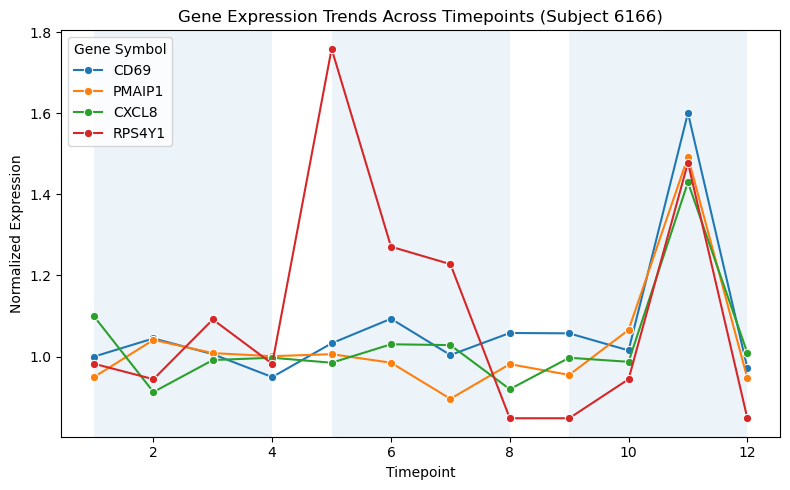

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

subject_id = "6166"
genes_to_plot = ["PMAIP1", "CXCL8", "CD69", "RPS4Y1"]

plot_df = norm_df.copy()
plot_df["ID_REF"] = plot_df["ID_REF"].astype(str)
plot_df = plot_df.merge(annot, on="ID_REF", how="left").dropna(subset=["Gene Symbol"])

one_subj = plot_df[
    (plot_df["subject"] == subject_id) &
    (plot_df["condition"] == "sleep_deprived") &
    (plot_df["Gene Symbol"].isin(genes_to_plot))
].copy()

plt.figure(figsize=(8,5))
sns.lineplot(data=one_subj, x="timepoint", y="norm_expr", hue="Gene Symbol", marker="o")
plt.axvspan(1, 4, alpha=0.08)
plt.axvspan(5, 8, alpha=0.08)
plt.axvspan(9, 12, alpha=0.08)
plt.title(f"Gene Expression Trends Across Timepoints (Subject {subject_id})")
plt.xlabel("Timepoint")
plt.ylabel("Normalized Expression")
plt.tight_layout()
plt.show()

In [53]:
# Selection criteria for pathway analysis

top_n = 200

# Experimental phase
top_exp = exp_ranked.head(top_n).copy()
print("Experimental phase")
print("Number of top genes selected:", len(top_exp))
print("Minimum FDR among selected genes:", top_exp["adj_p"].min())
print("Maximum FDR among selected genes:", top_exp["adj_p"].max())

# Recovery phase
top_rec = rec_ranked.head(top_n).copy()
print("\nRecovery phase")
print("Number of top genes selected:", len(top_rec))
print("Minimum FDR among selected genes:", top_rec["adj_p"].min())
print("Maximum FDR among selected genes:", top_rec["adj_p"].max())

Experimental phase
Number of top genes selected: 200
Minimum FDR among selected genes: 0.15344575491450277
Maximum FDR among selected genes: 0.8296116940565859

Recovery phase
Number of top genes selected: 200
Minimum FDR among selected genes: 0.15277291528726142
Maximum FDR among selected genes: 0.9151019226667046


In [57]:
# 1) How many genes have FDR < 0.2?

exp_fdr_02 = exp_ranked[exp_ranked["adj_p"] < 0.2].copy()
rec_fdr_02 = rec_ranked[rec_ranked["adj_p"] < 0.2].copy()

print("Experimental phase: genes with FDR < 0.2 =", len(exp_fdr_02))
print("Recovery phase: genes with FDR < 0.2 =", len(rec_fdr_02))

Experimental phase: genes with FDR < 0.2 = 18
Recovery phase: genes with FDR < 0.2 = 4


In [59]:
# Average normalized expression per timepoint

tp_avg = norm_df.groupby("timepoint")["norm_expr"].agg(["mean", "std"]).reset_index()

print(tp_avg)

    timepoint      mean       std
0           1  1.000055  0.036052
1           2  0.999906  0.032586
2           3  1.000127  0.039042
3           4  0.999913  0.033111
4           5  1.000398  0.045308
5           6  1.000900  0.055545
6           7  1.000314  0.043487
7           8  1.001115  0.060554
8           9  1.000464  0.047075
9          10  1.001048  0.058419
10         11  1.000982  0.057018
11         12  1.000976  0.056890


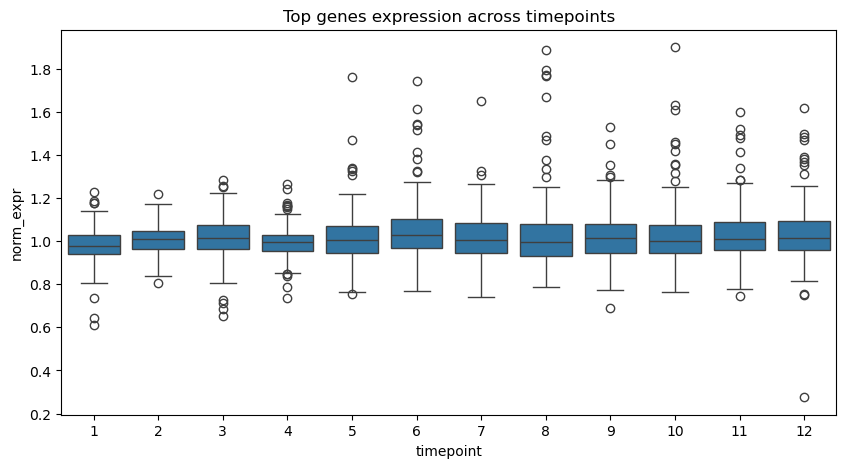

In [63]:
# Check top genes behavior across timepoints

# Fix datatype mismatch
norm_df["ID_REF"] = norm_df["ID_REF"].astype(str)
annot["ID_REF"] = annot["ID_REF"].astype(str)

# Now merge
check_df = norm_df.merge(annot, on="ID_REF", how="left")

# Filter top genes
top_genes = top_exp_genes.tolist()[:10]
check_df = check_df[check_df["Gene Symbol"].isin(top_genes)]

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(data=check_df, x="timepoint", y="norm_expr")
plt.title("Top genes expression across timepoints")
plt.show()

In [65]:
# Average + variability per timepoint

tp_summary = norm_df.groupby("timepoint")["norm_expr"].agg(
    mean="mean",
    std="std",
    median="median"
).reset_index()

print(tp_summary)

    timepoint      mean       std    median
0           1  1.000055  0.036052  1.000320
1           2  0.999906  0.032586  1.000190
2           3  1.000127  0.039042  0.999803
3           4  0.999913  0.033111  1.000460
4           5  1.000398  0.045308  1.000500
5           6  1.000900  0.055545  0.999849
6           7  1.000314  0.043487  1.000299
7           8  1.001115  0.060554  1.000853
8           9  1.000464  0.047075  1.000081
9          10  1.001048  0.058419  0.999690
10         11  1.000982  0.057018  1.000106
11         12  1.000976  0.056890  1.000107


In [69]:
# Experimental (FDR < 0.2)
exp_fdr_02 = exp_ranked[exp_ranked["adj_p"] < 0.2]

# Recovery (FDR < 0.3)
rec_fdr_03 = rec_ranked[rec_ranked["adj_p"] < 0.3]

print("Experimental phase (FDR < 0.2):", len(exp_fdr_02))
print("Recovery phase (FDR < 0.3):", len(rec_fdr_03))

Experimental phase (FDR < 0.2): 18
Recovery phase (FDR < 0.3): 23


In [73]:
print(exp_fdr_02.columns.tolist())
print(rec_fdr_03.columns.tolist())

['ID_REF', 'phase', 'case_mean', 'control_mean', 'diff', 'p_value', 'adj_p', 'significant', 'Gene Symbol']
['ID_REF', 'phase', 'case_mean', 'control_mean', 'diff', 'p_value', 'adj_p', 'significant', 'Gene Symbol']


In [75]:
print("\nExperimental genes (FDR < 0.2):")
print(exp_fdr_02.head(10))

print("\nRecovery genes (FDR < 0.3):")
print(rec_fdr_03.head(10))


Experimental genes (FDR < 0.2):
       ID_REF         phase  case_mean  control_mean      diff   p_value  \
2583  7985089  experimental   1.039169      0.972915  0.066254  0.000435   
7649  8154934  experimental   1.033147      0.986077  0.047070  0.000376   
6796  8125859  experimental   1.024274      0.981009  0.043265  0.000172   
3350  8008339  experimental   1.018926      0.978324  0.040602  0.000454   
1554  7949060  experimental   1.012421      0.980644  0.031778  0.000235   
7059  8134631  experimental   1.020080      0.993120  0.026960  0.000025   
6599  8119000  experimental   0.978579      1.008530 -0.029951  0.000093   
7238  8139859  experimental   0.990308      1.020447 -0.030139  0.000191   
85    7899361  experimental   0.980672      1.011361 -0.030689  0.000010   
6288  8110055  experimental   0.971040      1.003696 -0.032657  0.000288   

         adj_p  significant Gene Symbol  
2583  0.192988        False        RCN2  
7649  0.188319        False      IL11RA  
6796

In [77]:
print("\nExperimental genes (FDR < 0.2):")
print(exp_fdr_02[["Gene Symbol", "diff", "adj_p"]].head(10))

print("\nRecovery genes (FDR < 0.3):")
print(rec_fdr_03[["Gene Symbol", "diff", "adj_p"]].head(10))


Experimental genes (FDR < 0.2):
     Gene Symbol      diff     adj_p
2583        RCN2  0.066254  0.192988
7649      IL11RA  0.047070  0.188319
6796       TAF11  0.043265  0.153446
3350       RSAD1  0.040602  0.192988
1554    PPP1R14B  0.031778  0.153446
7059      ZNF655  0.026960  0.071323
6599      MAPK14 -0.029951  0.104966
7238        GUSB -0.030139  0.153446
85         STX12 -0.030689  0.056961
6288       CPEB4 -0.032657  0.174455

Recovery genes (FDR < 0.3):
      Gene Symbol      diff     adj_p
12965    IGKV6-21  0.146549  0.242531
13593   RN7SL672P  0.058064  0.242531
9128          SET  0.056959  0.152773
15765      PMS2P3  0.047302  0.242531
9728         IPO7  0.044605  0.242531
15342      FAM46A  0.041085  0.299186
14639        SKP2  0.039946  0.242531
13460       SRSF6  0.032766  0.242531
8659        PDE4B  0.031327  0.242531
9779      FAM111A  0.029025  0.152773


In [79]:
print("Experimental phase (FDR < 0.2):", len(exp_fdr_02))
print("Recovery phase (FDR < 0.3):", len(rec_fdr_03))

Experimental phase (FDR < 0.2): 18
Recovery phase (FDR < 0.3): 23


In [81]:
exp_sig_genes = exp_fdr_02["Gene Symbol"].dropna().drop_duplicates().tolist()
rec_sig_genes = rec_fdr_03["Gene Symbol"].dropna().drop_duplicates().tolist()

print("Experimental genes for enrichment:", exp_sig_genes)
print("Recovery genes for enrichment:", rec_sig_genes)
print(len(exp_sig_genes), len(rec_sig_genes))

Experimental genes for enrichment: ['RCN2', 'IL11RA', 'TAF11', 'RSAD1', 'PPP1R14B', 'ZNF655', 'MAPK14', 'GUSB', 'STX12', 'CPEB4', 'HIF1A', 'CCNK', 'CST7', 'GLE1', 'PPARD', 'PSTPIP2', 'KCTD20', 'C10orf12']
Recovery genes for enrichment: ['IGKV6-21', 'RN7SL672P', 'SET', 'PMS2P3', 'IPO7', 'FAM46A', 'SKP2', 'SRSF6', 'PDE4B', 'FAM111A', 'ARHGAP4', 'MKLN1', 'FDFT1', 'MED16', 'CST7', 'AIMP2', 'CFDP1', 'SNCA', 'HDGF', 'TMOD1', 'TSPAN5', 'EPB42', 'GLRX5']
18 23


In [83]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

exp_sig_enrich = gp.profile(organism="hsapiens", query=exp_sig_genes)
rec_sig_enrich = gp.profile(organism="hsapiens", query=rec_sig_genes)

keep_sources = ["KEGG", "REAC", "GO:BP", "GO:MF", "GO:CC", "WP"]

exp_sig_enrich = exp_sig_enrich[exp_sig_enrich["source"].isin(keep_sources)]
rec_sig_enrich = rec_sig_enrich[rec_sig_enrich["source"].isin(keep_sources)]

print(exp_sig_enrich[["source", "native", "name", "p_value", "significant"]].head(10))
print(rec_sig_enrich[["source", "native", "name", "p_value", "significant"]].head(10))

  source      native           name   p_value  significant
1   KEGG  KEGG:04148  Efferocytosis  0.025528         True
  source      native                                               name  \
0     WP   WP:WP5372  Involvement of secretase in neurodegenerative ...   
1  GO:CC  GO:0005938                                        cell cortex   

    p_value  significant  
0  0.025505         True  
1  0.032147         True  


In [85]:
merged_de = exp_ranked.merge(
    rec_ranked,
    on="ID_REF",
    suffixes=("_exp", "_rec")
)

# Add gene symbols
merged_de = merged_de.merge(annot, on="ID_REF", how="left")

print(merged_de.head())

    ID_REF     phase_exp  case_mean_exp  control_mean_exp  diff_exp  \
0  8176375  experimental       1.085297          0.981224  0.104073   
1  8030362  experimental       1.074300          0.972425  0.101874   
2  8043446  experimental       1.106015          1.016330  0.089685   
3  7989013  experimental       1.071558          0.987816  0.083742   
4  8021470  experimental       1.023663          0.943966  0.079697   

   p_value_exp  adj_p_exp  significant_exp Gene Symbol_exp phase_rec  \
0     0.005469   0.284955            False          RPS4Y1  recovery   
1     0.009313   0.296702            False         SNORD33  recovery   
2     0.088815   0.477576            False        IGKV6-21  recovery   
3     0.041049   0.388835            False         RSL24D1  recovery   
4     0.038368   0.387672            False          PMAIP1  recovery   

   case_mean_rec  control_mean_rec  diff_rec  p_value_rec  adj_p_rec  \
0       1.102590          0.968582  0.134008     0.015188   0.534328

In [87]:
# Recovery behavior

merged_de["recovery_gap"] = abs(merged_de["diff_rec"])
merged_de["exp_effect"] = abs(merged_de["diff_exp"])

# Sort genes with strong experimental effect
merged_sorted = merged_de.sort_values("exp_effect", ascending=False)

print(merged_sorted[[
    "Gene Symbol", "diff_exp", "diff_rec", "recovery_gap"
]].head(20))

        Gene Symbol  diff_exp  diff_rec  recovery_gap
7935      IGKV1D-27 -0.116420 -0.061878      0.061878
7934            HBZ -0.104878 -0.100973      0.100973
0            RPS4Y1  0.104073  0.134008      0.134008
1           SNORD33  0.101874  0.044147      0.044147
2          IGKV6-21  0.089685  0.146549      0.146549
7933     RNU6-1003P -0.087361 -0.006620      0.006620
3           RSL24D1  0.083742  0.030840      0.030840
4            PMAIP1  0.079697  0.074588      0.074588
5           CCDC167  0.078546  0.062943      0.062943
6       SNORD116-15  0.078042  0.026691      0.026691
7932       RNA5SP68 -0.077735 -0.010916      0.010916
7              CD69  0.077630  0.033763      0.033763
8           SNORD64  0.076013  0.012076      0.012076
9             CENPK  0.075875  0.031562      0.031562
10            PSMC6  0.074968  0.059527      0.059527
11            SNRPG  0.074864  0.018648      0.018648
12          TMEM256  0.073723  0.029257      0.029257
13            PSMC6  0.07322

In [89]:
def classify(row):
    if abs(row["diff_exp"]) > 0.03:
        if abs(row["diff_rec"]) < 0.02:
            return "Recovered"
        else:
            return "Not recovered"
    return "Weak"

merged_de["status"] = merged_de.apply(classify, axis=1)

print(merged_de["status"].value_counts())

status
Weak             7415
Recovered         268
Not recovered     253
Name: count, dtype: int64


In [91]:
recovered_genes = merged_de[merged_de["status"] == "Recovered"]["Gene Symbol"].dropna().unique().tolist()
not_recovered_genes = merged_de[merged_de["status"] == "Not recovered"]["Gene Symbol"].dropna().unique().tolist()

print("Recovered genes:", len(recovered_genes))
print("Not recovered genes:", len(not_recovered_genes))

Recovered genes: 246
Not recovered genes: 215


In [93]:
from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

recov_enrich = gp.profile(organism="hsapiens", query=recovered_genes)
persist_enrich = gp.profile(organism="hsapiens", query=not_recovered_genes)

keep_sources = ["KEGG", "REAC", "GO:BP", "GO:MF", "GO:CC", "WP"]

recov_enrich = recov_enrich[recov_enrich["source"].isin(keep_sources)]
persist_enrich = persist_enrich[persist_enrich["source"].isin(keep_sources)]

print("Recovered pathways:")
print(recov_enrich[["source", "name", "p_value"]].head(10))

print("\nPersistent pathways:")
print(persist_enrich[["source", "name", "p_value"]].head(10))

Recovered pathways:
  source                                               name       p_value
0  GO:CC                                  ribosomal subunit  2.234374e-07
1   KEGG                                           Ribosome  5.355896e-07
2  GO:CC                                 cytosolic ribosome  1.199838e-06
3   REAC  SRP-dependent cotranslational protein targetin...  1.240069e-06
4   REAC                             Viral mRNA Translation  1.295047e-06
5   REAC                           Peptide chain elongation  1.295047e-06
6     WP                     Cytoplasmic ribosomal proteins  1.449161e-06
7   REAC  Nonsense Mediated Decay (NMD) enhanced by the ...  1.679746e-06
8   REAC                      Nonsense-Mediated Decay (NMD)  1.679746e-06
9   REAC        Regulation of expression of SLITs and ROBOs  1.737536e-06

Persistent pathways:
  source           name   p_value
5   REAC  HIV Infection  0.043814
